## Fase 2: Exploración de datos (EDA)
### Importación y carga de Datos
Cargamos las librerías y el dataset.

In [1]:
# Importar las librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
# ----------------------------------------------------------------
# Configuración global
RANDOM_STATE = 100              # Semilla para reproducibilidad
np.random.seed(RANDOM_STATE)    # Fijar la semilla de NumPy

# Rutas de los archivos de datos
TRAIN_PATH = "/kaggle/input/retencion-de-clientes-de-una-entidad-financiera/train.csv"
TEST_PATH = "/kaggle/input/retencion-de-clientes-de-una-entidad-financiera/test.csv"
SAMPLE_SUB_PATH = "/kaggle/working/sample_submission.csv"

# Configuración visual
sns.set_style("whitegrid")          # Estilo de los gráficos
plt.rcParams['figure.figsize'] = (10, 6) # Tamaño por defecto de las figuras
pd.set_option("display.max_columns", 15) # Mostrar todas las columnas de los DataFrames
# ----------------------------------------------------------------

# Cargar los datos
# Asegúrate de que train.csv está en la misma carpeta que tu notebook
train_df = pd.read_csv(TRAIN_PATH)
test_df  = pd.read_csv(TEST_PATH)
#df_sample = pd.read_csv(SAMPLE_SUB_PATH)
# 3. Vista preliminar
print("Dimensiones del dataset:", train_df.shape)
print("Dimensiones de test :", test_df.shape)
#print("Dimensiones de sample_submission:", df_sample.shape)

display(train_df.head())
display(test_df.head())
#display(df_sample.head())

Dimensiones del dataset: (8000, 13)
Dimensiones de test : (2000, 12)


,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,15759244,Boone,687.0,Germany,Male,44,8,95368.14,2.0,1.0,1,1787.85,0
1,15725997,She,660.0,France,Female,35,6,100768.77,1.0,1.0,0,19199.61,0
2,15724296,Kerr,684.0,Spain,Male,41,2,119782.72,2.0,0.0,0,120284.67,0
3,15636820,Loggia,725.0,Germany,Male,40,8,104149.66,1.0,1.0,0,62027.90,0
4,15744529,Chiekwugo,510.0,France,Male,63,8,0.00,2.0,1.0,1,115291.86,0


,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,15764618,Tseng,815.0,Spain,Female,39,6,0.00,1.0,1.0,1,85167.88
1,15626385,George,714.0,Spain,Female,33,10,103121.33,2.0,1.0,1,49672.01
2,15687413,Sunderland,619.0,Spain,Female,38,6,0.00,2.0,1.0,1,117616.29
3,15759067,Bromby,537.0,Germany,Female,37,7,158411.95,4.0,1.0,1,117690.58
4,15614049,Hu,664.0,France,Male,55,8,0.00,2.0,1.0,1,139161.64


### Análisis de Calidad de Datos (Valores Nulos y Duplicados)

Antes de graficar, debemos saber si faltan datos, ya que esto dictará nuestra estrategia en la fase de Preprocesamiento de datos. Para ello, determinamos qué tipos de variables tenemos, si hay nulos y hay filas duplicadas en los conjuntos de datos train y test.


In [2]:
# Tipos de variables
print("Tipos variables (train):")
display(train_df.dtypes.to_frame("dtype").T)

# Búsqueda de nulos
na_train = train_df.isna().sum().sort_values(ascending=False)
na_test  = test_df.isna().sum().sort_values(ascending=False)

print("\nNúmero de valores nulos  en el conjunto de train:")
display(na_train[na_train > 0].to_frame("missing"))

print("\nNúmero de valores nulos en el conjunto de test:")
display(na_test[na_test > 0].to_frame("missing"))

# Búsqueda de duplicados (filas exactas)
dup_train = train_df.duplicated().sum()
dup_test  = test_df.duplicated().sum()
print(f"Duplicados exactos -> train: {dup_train}, test: {dup_test}")


Tipos variables (train):


,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
dtype,int64,object,float64,object,object,int64,int64,float64,float64,float64,int64,float64,int64



Número de valores nulos  en el conjunto de train:


,missing
CreditScore,1641
Balance,1615
NumOfProducts,976
EstimatedSalary,832
Surname,409
HasCrCard,375



Número de valores nulos en el conjunto de test:


,missing
CreditScore,414
Balance,400
NumOfProducts,243
EstimatedSalary,199
HasCrCard,94
Surname,90


Duplicados exactos -> train: 0, test: 0


A la vista de los resultado de las tablas anteriores podemos ver que, por un lado, el conjunto de datos tiene tanto variables numéricas como categóricas (mostradas como `object`), y por otro, se observa que el número de variables con valores perdidos es bastante elevado tanto en el conjunto de entrenamiento como el en de test.

* Pequeño análisis descriptivo de las variables

In [3]:
# Mostramos una estadística descriptiva rápida
display(train_df.describe(include="all").T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
CustomerId,8000.0,NaN,NaN,NaN,15691188.45225,71872.266617,15565701.0,15628959.75,15691115.0,15753727.75,15815690.0
Surname,7591,2523,Scott,25,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CreditScore,6359.0,NaN,NaN,NaN,661.235257,95.876126,350.0,595.0,664.0,729.0,850.0
Geography,8000,3,France,4030,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gender,8000,2,Male,4384,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,8000.0,NaN,NaN,NaN,38.935,10.381389,18.0,32.0,37.0,44.0,92.0
Tenure,8000.0,NaN,NaN,NaN,5.013875,2.88881,0.0,3.0,5.0,8.0,10.0
Balance,6385.0,NaN,NaN,NaN,76929.669179,62292.133487,0.0,0.0,98009.13,127660.46,250898.09
NumOfProducts,7024.0,NaN,NaN,NaN,1.539721,0.574125,1.0,1.0,2.0,2.0,4.0
HasCrCard,7625.0,NaN,NaN,NaN,0.706623,0.45534,0.0,0.0,1.0,1.0,1.0


## 2) Análisis exploratorio de datos (EDA) 

Con el objetivo de buscar y entender patrones en los datos vemos como se comportan las variables numéricas y categóricas con respecto a la variable objetivo.

### Tipos de variables 

1. Identificación del cliente

* ***CustomerId***: ID único del cliente
* ***Surname***: Apellido del cliente

2. Información financiera

* ***CreditScore***: Calificación crediticia. Establece la capacidad de una persona para pagar su deuda y el riesgo que conlleva invertir con ella.
* ***Balance***: Saldo en la cuenta bancaria
* ***NumOfProducts***: Número de productos bancarios que utiliza
* ***HasCrCard***: Si tiene tarjeta de crédito (0 = no, 1 = sí)
* ***EstimatedSalary***: Salario estimado

3. Información demográfica y personal

* ***Geography***: País de residencia
* ***Gender***: Género (Male/Female)
* ***Age***: Edad
* ***Tenure***: Años como cliente del banco
* ***IsActiveMember***: Si es un miembro activo del banco (0 = no, 1 = sí)

4. Variable objetivo

* ***Exited***: Indicador binario de abandono del banco (0 = se queda, 1 = se va)

### Tipo de datos

* ***Numéricos***: Integer o Float (*CustomerId, CreditScore, Age, Tenure, Balance, NumOfProducts,EstimatedSalary*)
* ***Categóricas***: *Gender, Geography, HasCrCard, IsActiveMember, Exited*

### Análisis de la distribución de la variable Objetivo (Exited)

Es crucial ver si el dataset está desbalanceado (muchos más "No" que "Sí"),

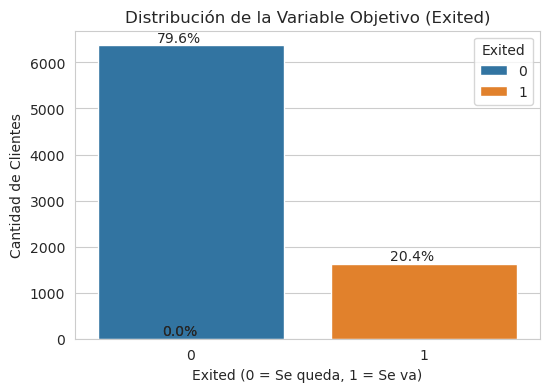

In [4]:
# Separar columnas numéricas y categóricas para facilitar el análisis
# Excluimos CustomerId y Surname ya que no aportan valor predictivo directo en el EDA
# Nota: 'NumOfProducts' se puede conciderar categórica si tiene pocos valores, pero funciona bien como numérica.
numeric_vars = ['CreditScore', 'Age', 'Tenure', 'Balance', 'EstimatedSalary']
categorical_vars = ['Geography', 'Gender', 'HasCrCard', 'IsActiveMember','NumOfProducts']
target = 'Exited'

plt.figure(figsize=(6, 4))
ax = sns.countplot(x=target, data=train_df, hue=target)

plt.title('Distribución de la Variable Objetivo (Exited)')
plt.xlabel('Exited (0 = Se queda, 1 = Se va)')
plt.ylabel('Cantidad de Clientes')

# Agregar etiquetas de porcentaje
total = len(train_df)
for p in ax.patches:
    percentage = '{:.1f}%'.format(100 * p.get_height()/total)
    x = p.get_x() + p.get_width() / 2 - 0.05
    y_train = p.get_height()
    ax.annotate(percentage, (x, y_train), ha='center', va='bottom')

plt.show()

Se observa un claro desbalance de clases con una clara ganadora que indica que, son más los cliente que permanecen que los que se abandonan la entidad. No obstante, el objetivo es predecir los que abandonan.

### Análisis de variables Categóricas vs Exited

Aquí analizamos cómo influye el pais de procedencia del cliente, el género, si tiene o no tarjeta de crédito o si es un miembro activo del banco frente al abandono o no de la entidad bancaria con el objetivo de encontrar un patrón/relación visual en los datos.

Destacar que aunque `NumofProduct`es una variable numérica, dado el número de valores discretos que tiene la tratamos como categórica.

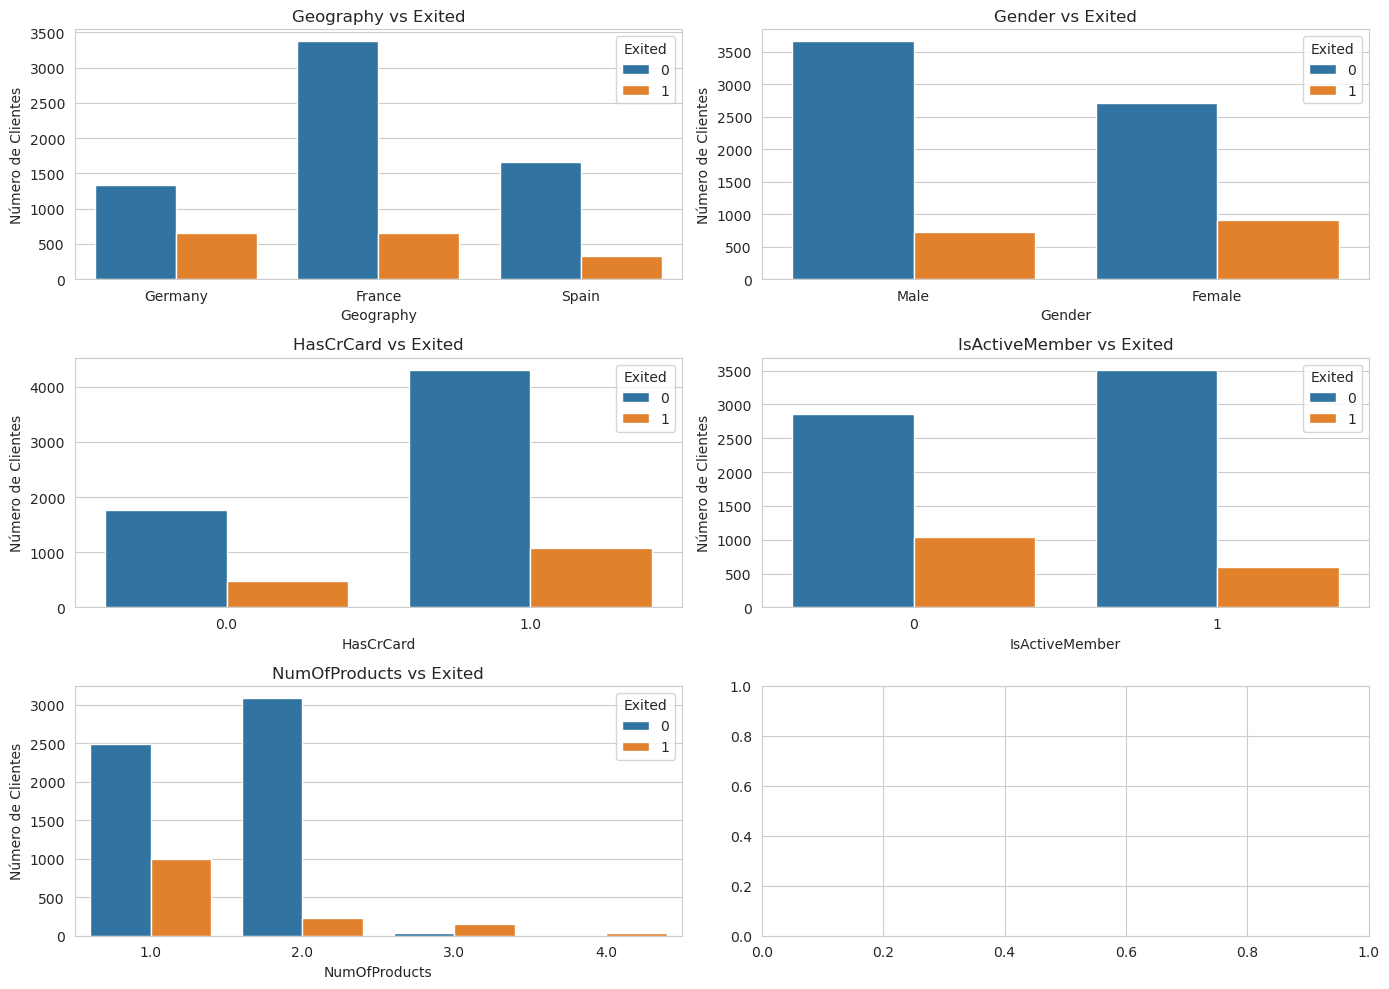

In [5]:
fig, axes = plt.subplots(3, 2, figsize=(14, 10))

for i, col in enumerate(categorical_vars):
    row = i // 2
    col_idx = i % 2
    
    sns.countplot(data=train_df, x=col, hue=target, ax=axes[row, col_idx])
    axes[row, col_idx].set_title(f'{col} vs Exited')
    axes[row, col_idx].set_ylabel('Número de Clientes')

plt.tight_layout()
plt.show()

--- Proporción de abandono para: Geography ---
Exited             0          1
Geography                      
France     83.697270  16.302730
Germany    67.421954  32.578046
Spain      83.568548  16.431452
--- Proporción de abandono para: Gender ---
Exited          0          1
Gender                      
Female  74.917035  25.082965
Male    83.508212  16.491788
--- Proporción de abandono para: HasCrCard ---
Exited             0          1
HasCrCard                      
0.0        78.989718  21.010282
1.0        80.066815  19.933185
--- Proporción de abandono para: IsActiveMember ---
Exited                  0          1
IsActiveMember                      
0               73.355601  26.644399
1               85.564752  14.435248
--- Proporción de abandono para: NumOfProducts ---
Exited                 0           1
NumOfProducts                       
1.0            71.354765   28.645235
2.0            92.928077    7.071923
3.0            19.672131   80.327869
4.0             0.0000

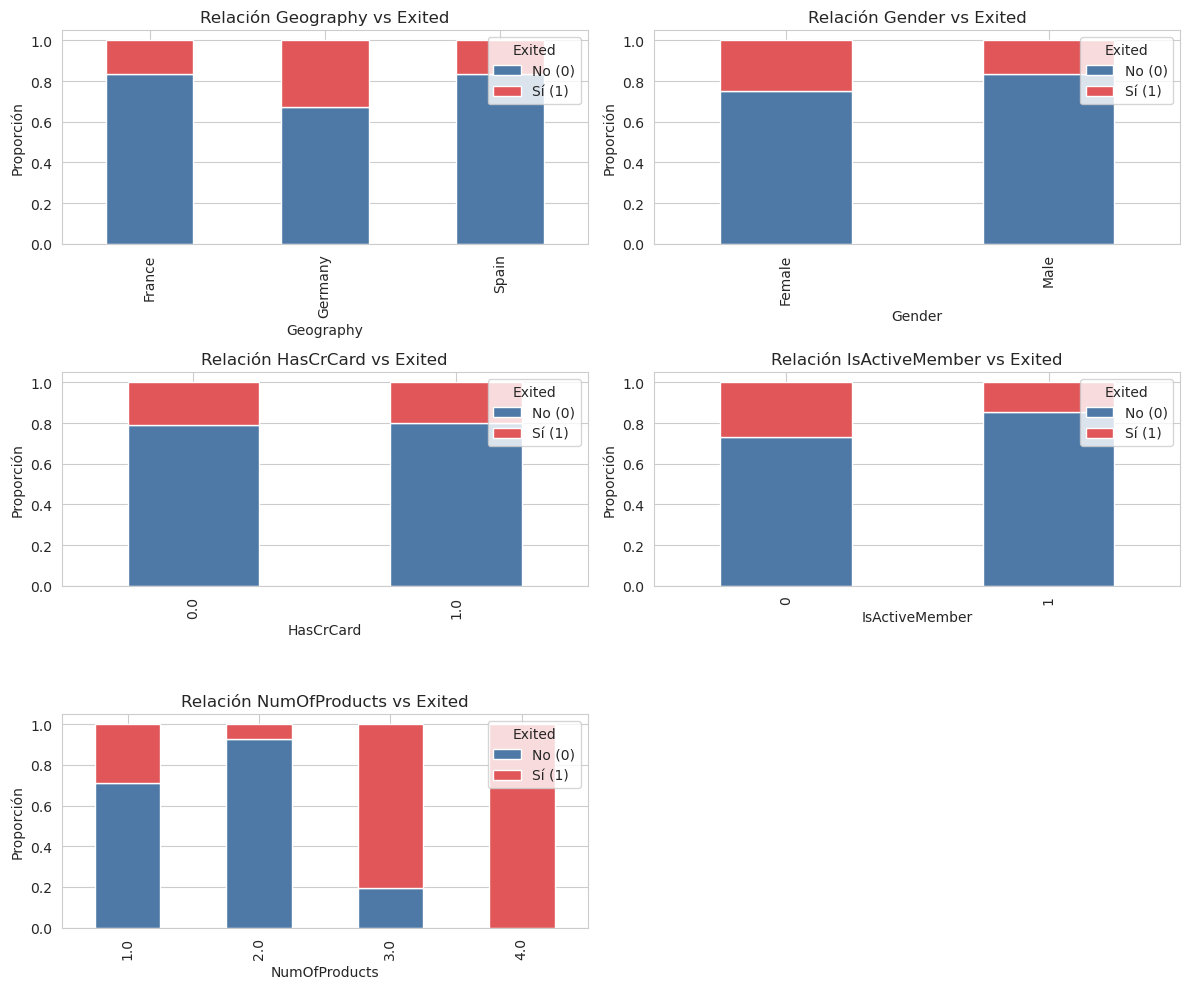

In [6]:
for col in categorical_vars:
    # Calcular la tabla cruzada normalizada por filas (index)
    # normalize='index' da el porcentaje entre 0 y 1 dentro de cada variable
    # Ejemplo, si en francia hay 100 clientes y 20 se van, el valor será 0.2 (20%)
    proporcion = pd.crosstab(train_df[col], train_df['Exited'], normalize='index') * 100
    
    print(f"--- Proporción de abandono para: {col} ---")
    print(proporcion)

# Visualización de proporciones de abandono por categoría
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(12,10))
fig.delaxes(axes[2,1]) # Eliminar el último hueco vacío si sobran

for i, col in enumerate(categorical_vars):
    # Crear la tabla cruzada
    cross_tab = pd.crosstab(train_df[col], train_df['Exited'])
    
    # Calcular posición del subplot
    ax = axes[i // 2, i % 2]
    
    # Generar el gráfico apilado
    cross_tab.div(cross_tab.sum(1).astype(float), axis=0).plot(
        kind='bar', stacked=True, ax=ax, color=['#4e79a7', '#e15759']
    )
    
    ax.set_title(f'Relación {col} vs Exited')
    ax.set_ylabel('Proporción')
    ax.legend(title='Exited', loc='upper right', labels=['No (0)', 'Sí (1)'])

plt.tight_layout()
plt.show()

De cada variable categórica y de las tasas podemos comentar lo siguiente: 

* *Geography*: se observa que los clientes de origen aleman tienen una tasa de abandono significativamente más alta que Francia o España. Aunque Francia suele tener más clientes en volumen, proporcionalmente los clientes alemanes son los más propensos a irse. Es un indicador de que esta variable es bastante predictiva.

Acción: Es obligatorio hacer un One-Hot Encoding aquí. No uses Label Encoding (0, 1, 2) porque no hay un orden ordinal entre países.

* *Gender*: se observa que las mujeres tienden a abandonar el banco en una proporción ligeramente mayor que los hombres en este conjunto de datos. Esto indica que el género es una variable importante dado que introduce un sesgo de comportamiento por género.

Acción: Codifícala también (0/1).

* *HasCrCard*: Observando las barras, el número de clientes que se quedan es mayor al número de clientes que van tanto si tienen o no tarjeta de credito. Pero si miramos proporciones, se ve que la proporción de abandono es casi idéntica tanto si tienen tarjeta (1) como si no (0). Por lo que esta variable por si sola introduce bastante ruido y tiene poco poder predictivo. 

Acción: Podrías plantearte eliminarla en una segunda iteración para simplificar el modelo, o cruzarla con otra variable (ej. HasCrCard * IsActiveMember).

* *IsActiveMember*: Hay una relación inversa muy clara . Los clientes no activos (0) se van mucho más que los activos (1). Podríamos considerarla una variable bastante importante porque introduce que el comportamiento o actividad actividad que tenga el cliente con el banco (activo) hace que los clientes no se vayan. 

Acción: Fundamental para el modelo.

* *NumOfProducts* :
Se observa un comportamiento no lineal del número de productos con respecto a la tasa de abandono:
    * Clientes con 1 producto: Tasa de abandono media/alta.
    * Clientes con 2 productos: Tasa de abandono muy baja (abandonan menos).
    * Clientes con 3 o 4 productos: Aunque el número de clientes con este número de productos es mucho menor, parece que la tasa de abandono es mucho más elevada. 
 
Consejo: Trátala con cuidado, a veces funciona mejor como categórica que como numérica pura.

### Análisis y distribución de variables numéricas vs Exited

Mostramos los histogramas de las variables numéricas para ver como se distribuyen frente a la variable Exited.

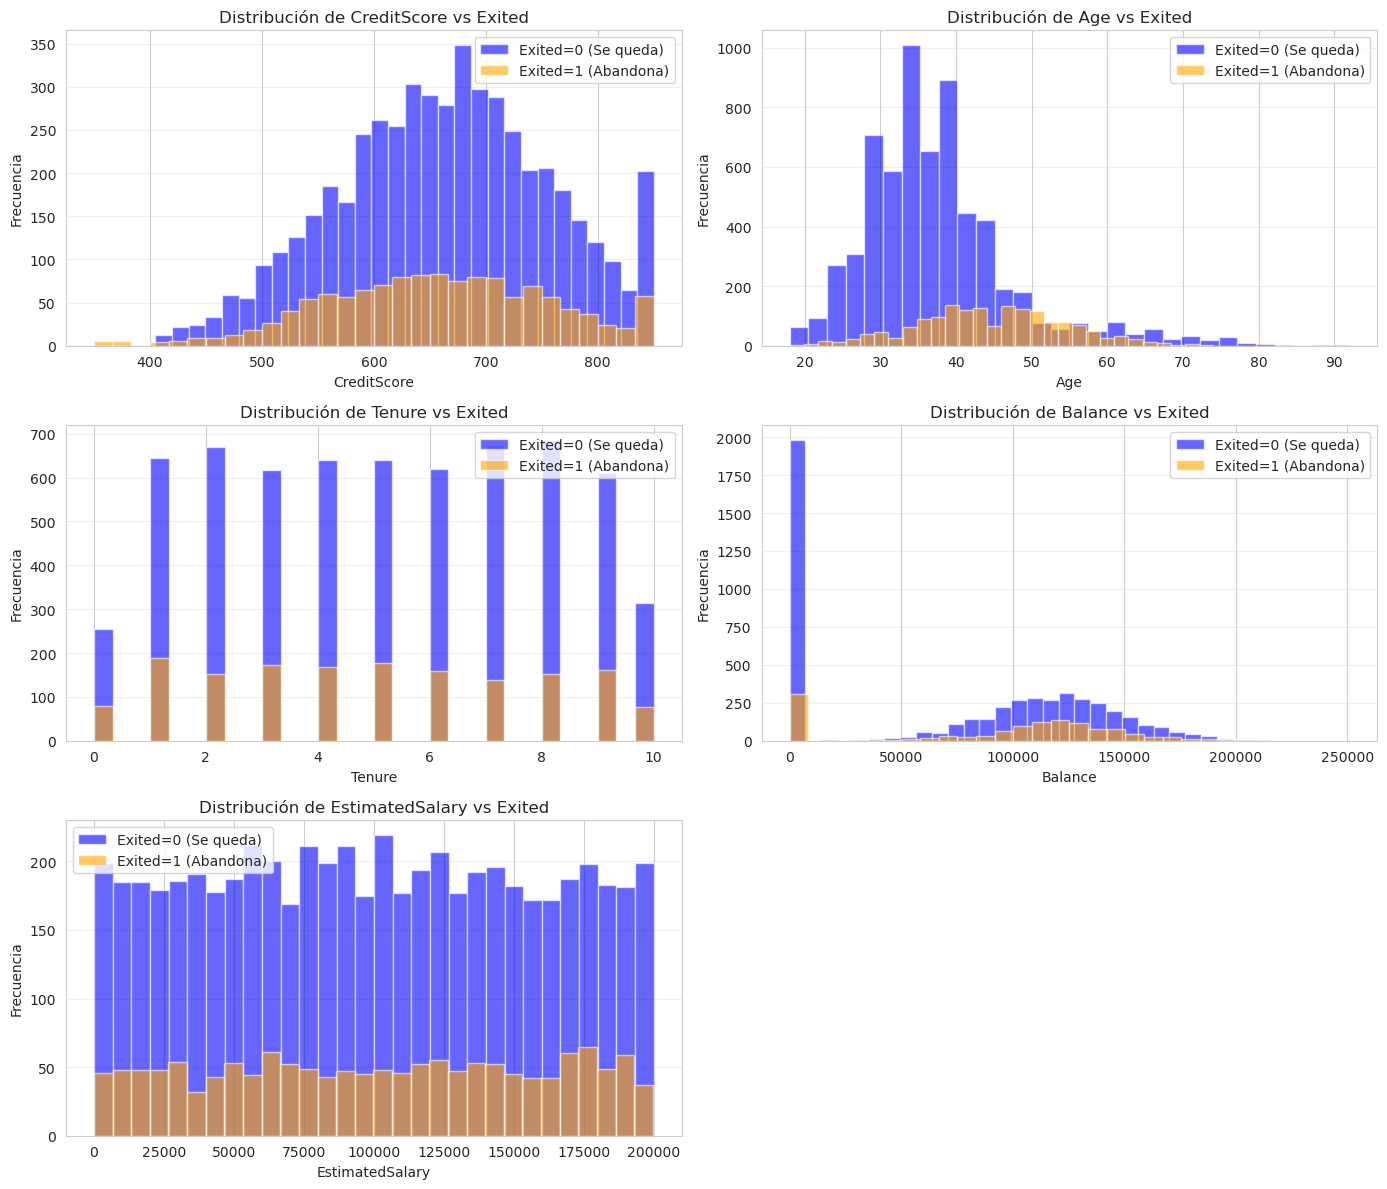

In [7]:
# ----Histogramas de variables numéricas-----
# Configuración de la matriz imágenes, número de filas y columnas
n_cols = 2
n_rows = math.ceil(len(numeric_vars) / n_cols)
# Creamos la figura y los ejes
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, n_rows * 4))
axes = axes.flatten() # Aplanamos para iterar fácilmente
fig.delaxes(axes[5]) # Eliminar el último hueco vacío si sobran
# Bucle para generar cada gráfico
for i, col in enumerate(numeric_vars):
    ax = axes[i] # Seleccionamos el hueco correspondiente   
    # Filtramos los datos por la clase objetivo
    # Usamos dropna() por seguridad, 
    tmp0 = train_df[train_df[target] == 0][col].dropna()
    tmp1 = train_df[train_df[target] == 1][col].dropna()
    # Graficamos ambos histogramas en el mismo eje (ax)
    ax.hist(tmp0, bins=30, alpha=0.6, label="Exited=0 (Se queda)", color='blue', edgecolor='white')
    ax.hist(tmp1, bins=30, alpha=0.6, label="Exited=1 (Abandona)", color='orange', edgecolor='white')
    # Etiquetas y título
    ax.set_title(f"Distribución de {col} vs {target}")
    ax.set_xlabel(col)
    ax.set_ylabel("Frecuencia")
    ax.legend()
    ax.grid(axis='y', alpha=0.3) # Rejilla horizontal suave para ayudar a leer alturas
# Ajuste de diseño y mostrar
plt.tight_layout()
plt.show()

* *Age* - Variable Crítica:
Se observa que las curvas no se superpon perfectamente. La curva de los que se quedan (0) está más sesgada hacia gente más joven (30-40 años), mientras que la curva de abandono (1) está hacia la derecha (45-55+ años). Esto indica que la edad es un predictor muy potente. Los clientes mayores tienden a abandonar más el banco que los jóvenes según los datos.

Consejo: Considera crear una nueva variable categórica (binned) como "Grupo_Edad" en la fase de ingeniería de características.

* *Balance* (Saldo en cuenta):
Se observa un pico enorme en 0, es decir, muchos clientes sin saldo. Habría que determinar si estos clientes se van porque no tiene actividad con el banco. 
Para los que tienen saldo, la distribución es normal (gaussiana) y no se aprecia diferencias en las tasas de abandono por balance en cuenta. 

* *CreditScore*: Se observa que la curva de abandono (1) o se queda (0) son casi idénticas, una campana de Gauss. Destacar un pequeño pico de abandonos en scores muy bajos (<400). Esta variable por sí sola, no parece discriminar mucho.

* *Tenure* (Antigüedad): Se observa que la distribución de esta variable es casi plana. Es decir, las barras de abandono y permanencia están muy mezcladas por lo que por si sola tiene bajo poder predictivo, lo que indica que la antiguedad del cliente en la entidad no determina fuertemente si se va o no.

* *EstimatedSalary* (Salario): Al igual que *Tenure* la distribución es casi plana y en este caso, que una persona gane mucho o poco, parece que no determina su estancia en la entidad.

Consejo: EstimatedSalary puede ser útil combinada con Balance (ratio Balance/Salario).

### Análisis de outliers y medianas.

Siguiendo con el análisis de distribución de los datos y outliers de variables numéricas, representamos las variables mediante los siguientes diagramas de cajas. 

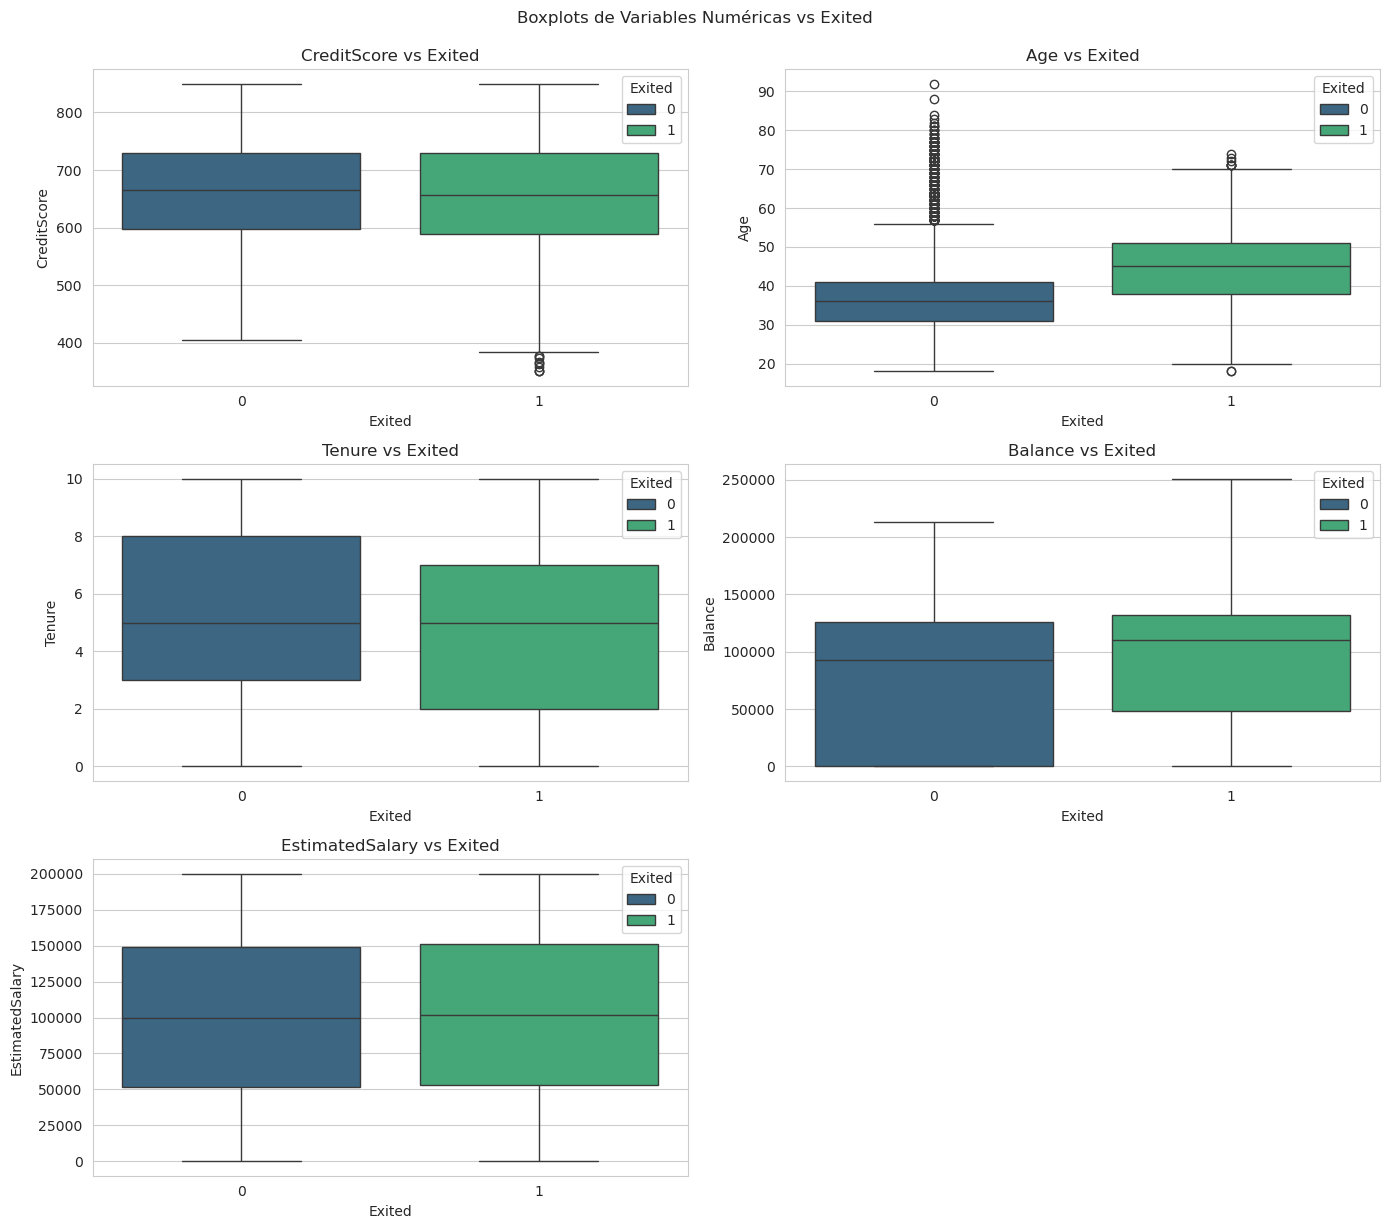

In [8]:
# Relación Numérica vs Target (Boxplots)
# Esto responde a tu petición de analizar "CreditScore vs Exited"
fig, axes = plt.subplots(3, 2, figsize=(14, 12))
fig.delaxes(axes[2,1]) # Eliminar el último hueco vacío si sobran
for i, col in enumerate(numeric_vars):
    row = i // 2
    col_idx = i % 2
    
    sns.boxplot(data=train_df, x=target, hue=target, y=col, ax=axes[row, col_idx], palette='viridis')
    axes[row, col_idx].set_title(f'{col} vs Exited')

plt.tight_layout()
plt.suptitle('Boxplots de Variables Numéricas vs Exited', y=1.02)
plt.show()

* *CreditScore* (Puntaje de Crédito)
La mediana se sitúa aproximadamente en 650 tanto para los clientes que se quedan como los que abandonan. La varianza es bastante compacta lo que indica que la gran mayoría de clientes tienen un CreditScore medio.

Destacar los outliers con valor por debajo de 400 para los clientes que se abandonan la entidad. Habría que determinar si estos abandonos de la entidad son abandonos por parte del cliente o, dado el número, por cierre de cuentas por parte del banco al no interesarles como clientes.  
    
Sugerencia: Verifica si estos outliers correlacionan con Exited = 1.

* *Age*: Se observa que la mediana está en torno a los 37-38 años para los clientes que se quedan en la entidad, mientras que los que abandonan están entorno a los 45-47 años.

En cuanto a varianza y sesgo de los clientes que se quedan se ve que la caja está "aplastada" hacia abajo y tiene un bigote superior muy largo. Esto indica un sesgo positivo (a la derecha) por lo que la distribución no es normal. 

En cuanto a outliers hay muchisimos en los clientes que se quedan en la parte superior (clientes mayores de 60/65 años). En cambio, hay unos pocos outliers los clientes que abandonan la entidad hay unos pocos para ese mismo rango de edad y un outlier particular para un cliente de menos de 20 años.  

Interpretación para el modelo: Esta suele ser la variable predictora más potente en este dataset clásico. Los clientes mayores a menudo tienen tasas de abandono muy diferentes a los jóvenes. 
    
Acción: Al haber tantos outliers, ten cuidado con la estandarización estándar (StandardScaler); podrías preferir RobustScaler o una transformación logarítmica si usas modelos lineales (para árboles de decisión como XGBoost, el orden importa más que la escala, así que afectará menos).

* *Tenure* (Antigüedad)
La mediana se centra en 5 años de antiguedad tanto para clientes que se quedan como los que se van. 
La varianza: La caja es amplia y muy simétrica.
No hay outliers. Los bigotes cubren todo el rango (de 0 a 10).

Es una distribución casi uniforme. Esto significa que tienes clientes de todas las antigüedades por igual. Por sí sola, puede no aportar mucho valor ("information gain" bajo), pero podría ser útil combinada con la edad (ej. ¿Joven con mucha antigüedad? Raro).

* *Balance* (Saldo en cuenta)
La mediana ronda los 90000 - 100000.
Varianza: La caja es muy grande (mucha dispersión). El rango intercuartílico es amplio.
Outliers: No se aprecian outliers significativos en los extremos de los bigotes.

Interpretación para el modelo: ¡Ojo con esta visualización! El boxplot es  engañoso aquí. En este dataset bancario, hay un gran grupo de clientes con Balance = 0 y el gráfico boxplot lo muestra como si estuvieran agregados. En el gráfico de barras se observa que se trata de una *distribución bimodal* (un pico en 0 y una campana de Gauss en torno a los 120000).

Sugerencia de Feature Engineering: Crea una variable binaria HasBalance (1 si > 0, 0 si = 0).

* *EstimatedSalary* (Salario Estimado)
La mediana se situa exactamente en el centro, alrededor del valor 100000.
La varianza tiene una caja muy cuadrada y simétrica.
No hay outliers.
Interpretación para el modelo: Parece una distribución perfectamente uniforme (ruido blanco). Esto suele indicar que es un dato estimado sintéticamente o que el banco tiene clientes de todos los niveles salariales exactamente en la misma proporción. Es probable que sea la variable con menor correlación con el abandono (Exited). No te sorprendas si tu modelo la descarta como poco importante.

### Análisis de la matriz de correlación

Para ver relaciones lineal entre variables numéricas y qué indican estas mostramos la matriz de correlación.

Nota: añadimos la variable `NumOfProducts` a la matriz de correlación dado que es una variable númerica que antes decidimos tratatarla como categórica para su análisis dado los pocos valores que posee.

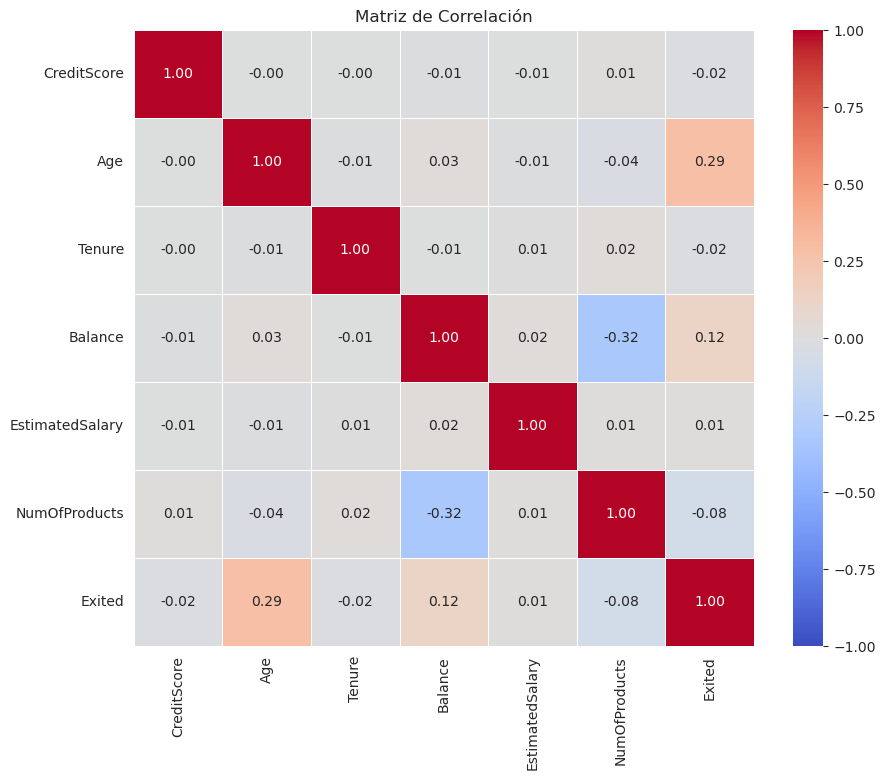

,Correlación con Exited
Exited,1.000000
Age,0.286788
Balance,0.122234
EstimatedSalary,0.011856
Tenure,-0.023380
CreditScore,-0.023388
NumOfProducts,-0.081740


In [9]:
plt.figure(figsize=(10, 8))

# Calculamos correlación solo de las numéricas + target
# Añadimos la variable 'NumOfProducts' como numérica
corr_matrix = train_df[numeric_vars + ["NumOfProducts"] + [target]].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5,vmin=-1, vmax=1, )
plt.title('Matriz de Correlación')
plt.show()
if target in corr_matrix.columns:
    display(corr_matrix[target].sort_values(ascending=False).to_frame("Correlación con Exited"))

Las relaciones de cada atributo con la variable objetivo podemos decir lo siguiente:  
* `Age vs Exited`: es la variable con mayor correlación con `Exited` siendo esta positiva, lo que indica que en este dataset, a mayor edad más riesgo de abandono de la entidad. Esto se puede verificar en el gráfico de bigotes. 
* `Balance`: Aunque hay muchos clientes con Balance cercano a 0 que abandonan la entidad como se ve en el histograma, esta variable tiene una ligera correlación positiva puede indicar que clientes con más dinero en la cuenta tienden a irse.

Destacando otras relaciones, pueden ser las siguientes:

* `NumOfProducts vs. Balance`: Es la mayor correlación negativa que hay en el conjunto de variables. Esto puede indicar que cuanto mayor es el número de productos (créditos, préstamos,...) que tiene un cliente, menor es el balance que tiene en su cuenta. 

**importante para tu Fase 3 (Feature Engineering); quizás el "Balance por Producto" sea una variable sintética potente.**



### Conclusiones del EDA

recopilar algo de arriba

## Fase 3: Preprocesamiento con Pipelines

Recomendación para la Fase 3 (Preprocesamiento)

Dado que usas sklearn.pipeline, recuerda definir transformadores separados para numéricas y categóricas:

    Numéricas (Age, Balance...): StandardScaler (XGBoost no lo necesita estrictamente, pero Regresión Logística sí).

    Categóricas (Geography, Gender): OneHotEncoder (Geography: France/Spain/Germany es vital, Germany suele tener mayor tasa de abandono)


Recomendación práctica:

Separa columnas:

Numéricas: imputación (mediana) + (opcional) escalado.

Categóricas: imputación (moda) + one-hot (handle_unknown='ignore').

Decide qué hacer con:

CustomerId: normalmente se elimina (identificador).

Surname: para empezar, elimínala (si la one-hot te explota en dimensiones). Más adelante, si quieres mejorar: “surname_length”, primera letra, o técnicas de codificación más avanzadas (pero ya es nivel medio/avanzado).

## Preprocesamiento - Linea base ( 1ª iteración)

### Tratamiento de valores nulos tanto en numéricas (ej. CreditScore) como en categóricas.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score
from sklearn.model_selection import cross_val_score, StratifiedKFold
# Rutas de los archivos de datos
TRAIN_PATH = "/kaggle/input/retencion-de-clientes-de-una-entidad-financiera/train.csv"
TEST_PATH = "/kaggle/input/retencion-de-clientes-de-una-entidad-financiera/test.csv"
SUBMISSION_PATH = "/kaggle/working/submission.csv"


# Cargamos de nueovo los datos para el pipeline
train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)
# Definir variables objetivo
TARGET = 'Exited'
# Variables numéricas: Incluyo las continuas y las binarias numéricas (HasCrCard, IsActiveMember)
NUM_FEATURES = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary', 'HasCrCard', 'IsActiveMember']
# Variables categóricas: Las de texto con pocas categorías
CAT_FEATURES = ['Geography', 'Gender']
# Variables a eliminar inicialmente (IDs y apellido)
DROP_FEATURES = ['CustomerId', 'Surname']
RANDOM_STATE = 100            # Semilla para reproducibilidad

# 1. Preparación de Datos
# Separar X_train e y_train por convención
# X_train = variables independientes
# y_train = variable dependiente u objetivo
X_train = train_df.drop(columns=[TARGET])
y_train = train_df[TARGET]

# Construcción de Pipelines de Preprocesamiento
# Dado que hay valores nulos en los datos,la imputación es obligatoria.

# Pipeline Numérico
num_pipeline = Pipeline(
    steps=[
    # Estrategia: Mediana para ser robusto ante outliers (ej. salarios muy altos)
    ('imputer', SimpleImputer(strategy='median')),
    # Escalado: Fundamental para modelos lineales y redes neuronales
    ('scaler', StandardScaler()) 
])

# Pipeline Categórico
cat_pipeline = Pipeline(
    steps=[
    # Estrategia: Rellenar con el más frecuente (moda)
    ('imputer', SimpleImputer(strategy='most_frequent')),
    # Codificación: OneHot para convertir "France", "Germany" en números (0, 1)
    # handle_unknown='ignore' es CRÍTICO para que no falle si en test aparece algo raro
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

# Preprocesador Maestro
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_pipeline, NUM_FEATURES),
        ('cat', cat_pipeline, CAT_FEATURES)
    ],
    # 'remainder="drop"' elimina automáticamente CustomerId y Surname
    remainder='drop' 
)

# 3. Pipeline Completo (Preprocesamiento + Modelo)
# Empezamos con LinearDiscriminantAnalysis como línea base (simple y rápida) 
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LinearDiscriminantAnalysis() )
])

#4. Validación Local (Fase 4 adelantada)
#Separamos un 20% para validar antes de subir a Kaggle
#Stratify para mantener la proporción de clases en train/val
X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(
    X_train, y_train, test_size=0.2, random_state=RANDOM_STATE, stratify=y_train)
# Entrenar el modelo para validar localmente con el split de train
model_pipeline.fit(X_train_split, y_train_split)
# Predecir y Evaluar
y_pred_val = model_pipeline.predict(X_val_split)
f1 = f1_score(y_val_split, y_pred_val)

print(f"F1-Score en Validación (Línea Base): {f1:.4f}")

# 4. Validación Cruzada (El cambio principal)
# Configuración: 5 splits (divisiones) es el estándar de la industria.
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Ejecutamos la validación.
# scoring='f1' es la métrica que pide Kaggle/tu documento.
cv_scores = cross_val_score(
    model_pipeline, 
    X_train, 
    y_train, 
    cv=cv_strategy, 
    scoring='f1',
    n_jobs=-1 # Nº de núcleos de CPU -1= todos 
)

# Resultados
print(f"--- Resultados de Validación Cruzada (5-Fold) ---")
print(f"F1-Scores individuales: {cv_scores}")
print(f"F1-Score Medio: {cv_scores.mean():.4f}")
print(f"Desviación Estándar: {cv_scores.std():.4f}")
# Interpretación de la desviación:
# Si es baja (< 0.02), tu modelo es estable.
# Si es alta, tu modelo depende de la suerte de los datos que le toquen.

# 5. Generación de Submission para Kaggle (Fase 5)
# Re-entrenamos con TODOS los datos de train para la predicción final
model_pipeline.fit(X_train, y_train) 
test_predictions = model_pipeline.predict(test_df)

# Crear fichero de salida
submission = pd.DataFrame({
    'CustomerId': test_df['CustomerId'],
    'Exited': test_predictions
})
submission.to_csv(SUBMISSION_PATH, index=False)
print(f"Fichero '{SUBMISSION_PATH}' generado correctamente.")

F1-Score en Validación (Línea Base): 0.3534


--- Resultados de Validación Cruzada (5-Fold) ---
F1-Scores individuales: [0.31363636 0.35095137 0.30472103 0.32017544 0.33920705]
F1-Score Medio: 0.3257
Desviación Estándar: 0.0169
Fichero '/kaggle/working/submission.csv' generado correctamente.
